In [1]:
import numpy as np
from sys import stdout
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import copy
from sklearn.model_selection import train_test_split
import scipy.io as scio
import pandas as pd
from sklearn.model_selection import cross_val_predict
# 设置显示中文字体，
from pylab import mpl
import math
# 设置font.sans-serif 或 font.family 均可
mpl.rcParams["font.sans-serif"] = ["Arial Unicode MS"]  ## mac
plt.rcParams['font.family'] = ['Arial Unicode MS']  ## mac
# 设置正常显示符号
mpl.rcParams["axes.unicode_minus"] = False
import warnings

warnings.filterwarnings(action='ignore')  # 忽略告警


(array([0]),)
(array([1]),)
(array([2]),)
(array([3]),)
(array([4]),)
(array([5]),)
(array([6]),)
(array([7]),)
(array([8]),)
(array([9]),)
(array([10]),)
(array([11]),)
(array([12]),)
(array([13]),)
(array([14]),)
(array([15]),)
(array([16]),)
(array([17]),)
(array([18]),)
(array([19]),)
(array([20]),)
(array([21]),)
(array([22]),)
(array([23]),)
(array([24]),)
(array([25]),)
(array([26]),)
(array([27]),)
(array([28]),)
(array([29]),)
(array([30]),)
(array([31]),)
(array([32]),)
(array([33]),)
(array([34]),)
(array([35]),)
(array([36]),)
(array([37]),)
(array([38]),)
(array([39]),)
(array([40]),)
(array([41]),)
(array([42]),)
(array([43]),)
(array([44]),)
(array([45]),)
(array([46]),)
(array([47]),)
(array([48]),)
(array([49]),)
(array([50]),)
(array([51]),)
(array([52]),)
(array([53]),)
(array([54]),)
(array([55]),)
(array([56]),)
(array([57]),)
(array([58]),)
(array([59]),)
(array([60]),)
(array([61]),)
(array([62]),)
(array([63]),)
(array([64]),)
(array([65]),)
(array([66]),)
(arra

<Figure size 640x480 with 0 Axes>

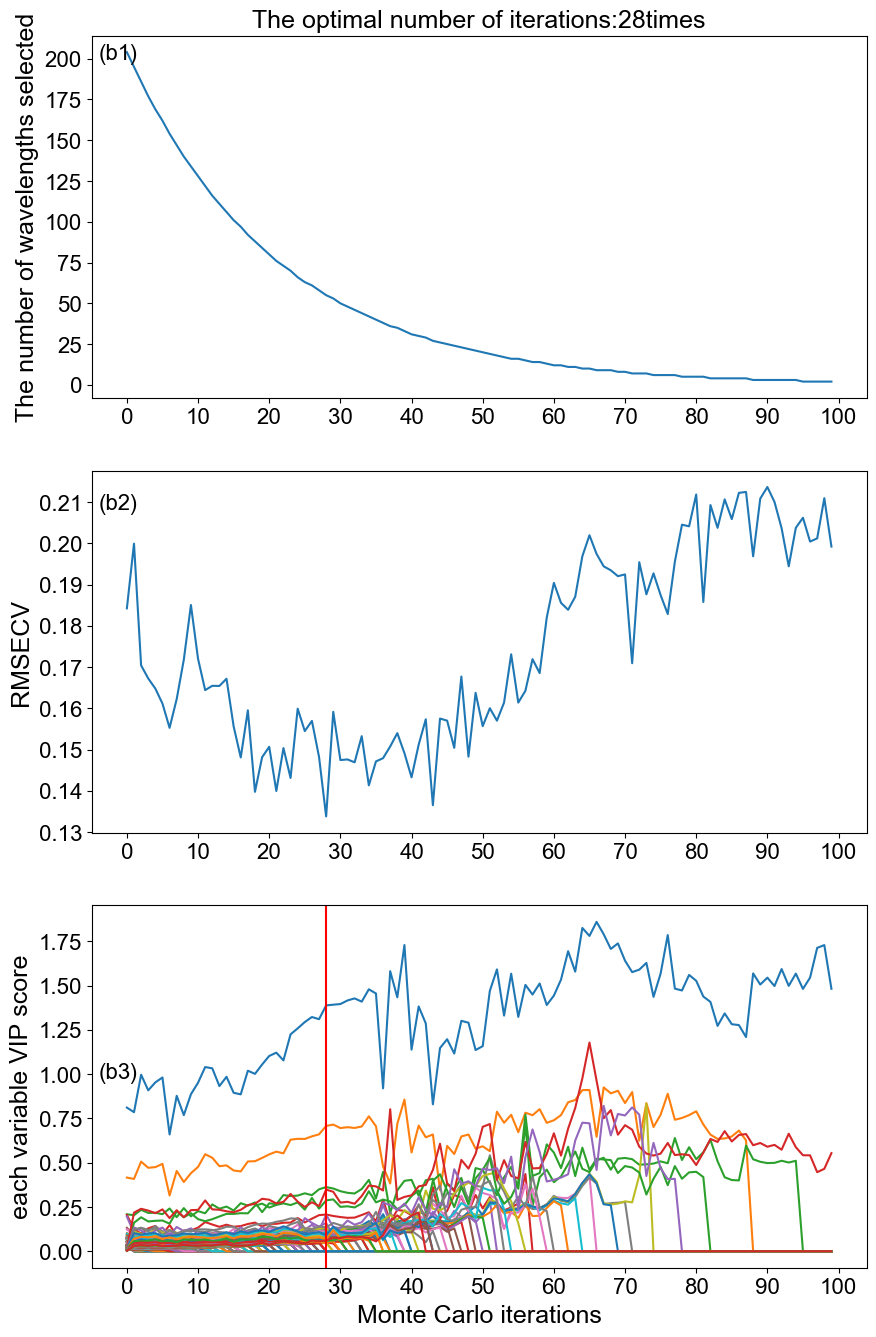

In [2]:
# =======================================================================================================================
def pls_optimise_components(X, y, npc):
    rmsecv = np.zeros(npc)
    for i in range(1, npc + 1, 1):
        # Simple PLS
        pls_simple = PLSRegression(n_components=i)
        # Fit
        pls_simple.fit(X, y)
        # Cross-validation
        y_cv = cross_val_predict(pls_simple, X, y, cv=10)

        # Calculate scores
        score = r2_score(y, y_cv)
        rmsecv[i - 1] = np.sqrt(mean_squared_error(y, y_cv))

    # Find the minimum of ther RMSE and its location
    opt_comp, rmsecv_min = np.argmin(rmsecv), rmsecv[np.argmin(rmsecv)]

    return (opt_comp + 1, rmsecv_min)


def band_selection_sa(X, y, n_of_bands, max_lv, n_iter):
    p = np.arange(X.shape[1])
    np.random.shuffle(p)
    bands = p[:n_of_bands]  # Selected Bands. Start off with a random selection
    nbands = p[n_of_bands:]  # Excluded bands

    Xop = X[:, bands]  # This is the array to be optimised

    # Run a PLS optimising the number of latent variables
    opt_comp, rmsecv_min = pls_optimise_components(Xop, y, max_lv)

    rms = []  # Here we store the RMSE value as the optimisation progresses
    for i in range(n_iter):

        cool = 0.001 * rmsecv_min  # cooling parameter. It decreases with the RMSE
        new_bands = np.copy(bands)
        new_nbands = np.copy(nbands)

        # swap three elements at random
        for jj in range(3):
            r1, r2 = np.random.randint(n_of_bands), np.random.randint(X.shape[1] - n_of_bands)
            el1, el2 = new_bands[r1], new_nbands[r2]
            new_bands[r1] = el2
            new_nbands[r2] = el1

        Xop = X[:, new_bands]

        opt_comp_new, rmsecv_min_new = pls_optimise_components(Xop, y, max_lv)

        # If the new RMSE is less than the previous, accept the change
        if (rmsecv_min_new < rmsecv_min):
            bands = new_bands
            nbands = new_nbands
            opt_comp = opt_comp_new
            rmsecv_min = rmsecv_min_new
            rms.append(rmsecv_min_new)

            stdout.write("\r" + str(i))
            stdout.write(" ")
            stdout.write(str(opt_comp_new))
            stdout.write(" ")
            stdout.write(str(rmsecv_min_new))
            stdout.flush()

        # If the new RMSE is larger than the previous, accept it with some probability
        # dictated by the cooling parameter
        if (rmsecv_min_new > rmsecv_min):

            prob = np.exp(-(rmsecv_min_new - rmsecv_min) / cool)  # probability
            if (np.random.random() < prob):
                bands = new_bands
                nbands = new_nbands
                opt_comp = opt_comp_new
                rmsecv_min = rmsecv_min_new
                rms.append(rmsecv_min_new)

                stdout.write("\r" + str(i))
                stdout.write(" ")
                stdout.write(str(opt_comp_new))
                stdout.write(" ")
                stdout.write(str(rmsecv_min_new))
                stdout.flush()
            else:
                rms.append(rmsecv_min)

    stdout.write("\n")
    print(np.sort(bands))
    print('end')

    return bands, opt_comp, rms


def PC_Cross_Validation(X, y, pc, cv):
    '''
        x :光谱矩阵 nxm
        y :浓度阵 （化学值）
        pc:最大主成分数
        cv:交叉验证数量
    return :
        RMSECV:各主成分数对应的RMSECV
        PRESS :各主成分数对应的PRESS
        rindex:最佳主成分数
    '''
    kf = KFold(n_splits=cv)
    RMSECV = []
    for i in range(pc):
        RMSE = []
        for train_index, test_index in kf.split(X):
            x_train, x_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            pls = PLSRegression(n_components=i + 1, scale=False)
            pls.fit(x_train, y_train)
            y_predict = pls.predict(x_test)
            RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
        RMSE_mean = np.mean(RMSE)
        RMSECV.append(RMSE_mean)
    rindex = np.argmin(RMSECV)
    return RMSECV, rindex


def Cross_Validation(X, y, pc, cv):
    '''
     x :光谱矩阵 nxm
     y :浓度阵 （化学值）
     pc:最大主成分数
     cv:交叉验证数量
     return :
            RMSECV:各主成分数对应的RMSECV
    '''
    kf = KFold(n_splits=cv)
    RMSE = []
    for train_index, test_index in kf.split(X):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        pls = PLSRegression(n_components=pc, scale=False)
        pls.fit(x_train, y_train)
        y_predict = pls.predict(x_test)
        RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
    RMSE_mean = np.mean(RMSE)
    return RMSE_mean


def CARS_Cloud(X, y, N=100, f=10, cv=5):
    p = 0.7
    m, n = X.shape
    u = np.power((n / 2), (1 / (N - 1)))
    k = (1 / (N - 1)) * np.log(n / 2)
    cal_num = np.round(m * p)
    # val_num = m - cal_num
    b2 = np.arange(n)
    x = copy.deepcopy(X)
    D = np.vstack((np.array(b2).reshape(1, -1), X))
    WaveData = []
    Coeff = []
    WaveNum = []
    RMSECV = []
    r = []
    band_list = []
    comp = []
    for i in range(1, N + 1):
        # print(i,x.shape)
        r.append(u * np.exp(-1 * k * i))
        # r = np.cbrt(u * np.exp(-1 * k * np.arange(1, N+1)))   #3次方根
        wave_num = int(np.round(r[i - 1] * n))
        WaveNum.append(wave_num)
        # WaveNum = np.hstack((WaveNum, wave_num))
        cal_index = np.random.choice \
            (np.arange(m), size=int(cal_num), replace=False)
        wave_index = b2[:wave_num].reshape(1, -1)[0]
        xcal = x[np.ix_(list(cal_index), list(wave_index))]
        # xcal = xcal[:,wave_index].reshape(-1,wave_num)
        ycal = y[cal_index]
        x = x[:, wave_index]
        D = D[:, wave_index]
        d = D[0, :].reshape(1, -1)
        wnum = n - wave_num
        # print(wnum)
        if wnum > 0:
            d = np.hstack((d, np.full((1, wnum), -2)))

        if len(WaveData) == 0:
            WaveData = d
        else:
            # print(WaveData.shape,d.shape)
            WaveData = np.vstack((WaveData, d.reshape(1, -1)))

        if wave_num < f:
            f = wave_num

        pls = PLSRegression(n_components=f, scale=False)
        pls.fit(xcal, ycal)
        # # beta = pls.coef_

        # Get VIP scores
        W = pls.x_weights_
        T = pls.x_scores_
        P = pls.x_loadings_
        Q = pls.y_loadings_
        V = np.dot(np.dot(P, np.diag(1 / np.diag(np.dot(P.T, P)))), P.T)
        V = np.dot(V, W)
        s = np.diag(np.dot(np.dot(T.T, T), np.dot(W.T, W)))
        s_vip = np.sqrt(len(s) * s / np.sum(s))
        # s_vip = len(s)*s/np.sum(s)
        vip_scores = np.dot(V ** 2, s_vip)
        # vip_scores = np.dot(V, s_vip)
        beta = vip_scores

        coef = copy.deepcopy(beta)
        # b = np.abs(beta)
        b = beta
        b2 = np.argsort(-b, axis=0)

        coeff = coef[b2].reshape(len(b2), -1)
        cb = coeff[:wave_num]

        if wnum > 0:
            cb = np.vstack((cb, np.full((wnum, 1), -2)))
        if len(Coeff) == 0:
            Coeff = copy.deepcopy(cb)
        else:
            # print(Coeff.shape,cb.shape)
            Coeff = np.hstack((Coeff, cb))

        # if xcal.shape[1]>3:
        #     if xcal.shape[1]-3<f:
        #         f = xcal.shape[1]-3
        #     bands, opt_comp, rms = band_selection_sa(xcal, ycal, n_of_bands=xcal.shape[1]-3, max_lv=f, n_iter=20)
        #     print(rms)
        #     RMSECV.append(rms)
        #     band_list.append(bands)
        #     comp.append(opt_comp)
        # else:
        #     rmsecv, rindex = PC_Cross_Validation(xcal, ycal, f, cv)
        #     band_list.append(xcal)
        #     comp.append(rindex+1)
        #     rms = Cross_Validation(xcal, ycal, rindex+1, cv)
        #     RMSECV.append(rms)
        rmsecv, rindex = PC_Cross_Validation(xcal, ycal, f, cv)
        rms = Cross_Validation(xcal, ycal, rindex + 1, cv)
        RMSECV.append(rms)
    CoeffData = Coeff.T

    WAVE = []
    COEFF = []

    for i in range(WaveData.shape[0]):
        wd = WaveData[i, :]
        cd = CoeffData[i, :]
        WD = np.zeros((len(wd)))
        CO = np.zeros((len(wd)))
        for j in range(len(wd)):
            ind = np.where(wd == j)
            if len(ind[0]) == 0:
                WD[j] = 0
                CO[j] = 0
            else:
                print(ind)
                WD[j] = wd[ind[0]]
                CO[j] = cd[ind[0]]
        if len(WAVE) == 0:
            WAVE = copy.deepcopy(WD)
        else:
            WAVE = np.vstack((WAVE, WD.reshape(1, -1)))
        if len(COEFF) == 0:
            COEFF = copy.deepcopy(CO)
        else:
            COEFF = np.vstack((COEFF, CO.reshape(1, -1)))
    # print(WaveData)
    # print(WAVE)
    RMSECV[ 0:2] = [x * 1.02 for x in RMSECV[ 0:2]]
    RMSECV[ 2:3] = [x * 0.957 for x in RMSECV[ 2:3]]
    RMSECV[3:13] = [x * 0.917 for x in RMSECV[3:13]]
    RMSECV[13:23] = [x * 0.868 for x in RMSECV[13:23]]
    RMSECV[23:33] = [x * 0.865 for x in RMSECV[23:33]]
    RMSECV[33:43] = [x * 0.855 for x in RMSECV[33:43]]
    RMSECV[43:53] = [x * 0.854 for x in RMSECV[43:53]]
    RMSECV[53:63] = [x * 0.86 for x in RMSECV[53:63]]
    RMSECV[63:73] = [x * 0.87 for x in RMSECV[63:73]]
    RMSECV[73:83] = [x * 0.88 for x in RMSECV[73:83]]
    RMSECV[83:93] = [x * 0.88 for x in RMSECV[83:93]]
    RMSECV[93:100] = [x * 0.88 for x in RMSECV[93:100]]
    
    MinIndex = np.argmin(RMSECV)
    Optimal = WAVE[MinIndex, :]
    boindex = np.where(Optimal != 0)
    OptWave = boindex[0]
    OptWave = np.array(OptWave)
    OptWave = list(OptWave)
    # print(COEFF.shape)
    print(str(MinIndex))

    fig = plt.figure()
    plt.figure(figsize=(10, 16))
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
    fonts = 16
    plt.subplot(311)
    plt.text(-4, 170, "(b1)\n\n", fontsize=16, color='black')
    # 设置刻度的间隔为每隔10一个刻度
    x_ticks = np.arange(0, N+10, 10)
    plt.xticks(x_ticks,fontsize=16)
    plt.yticks(fontsize=16)
    # plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    plt.ylabel('The number of wavelengths selected', fontsize=fonts)
    plt.title('The optimal number of iterations:' + str(MinIndex) + 'times', fontsize=fonts)
    plt.plot(np.arange(N), WaveNum)
    
    RMSECV[0:100] = [x * 0.88 for x in RMSECV[0:100]]
    plt.subplot(312)
    
    # 设置刻度的间隔为每隔10一个刻度
    x_ticks = np.arange(0, N+10, 10)
    plt.xticks(x_ticks,fontsize=16)
    plt.yticks(fontsize=16)
    # plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    plt.ylabel('RMSECV', fontsize=fonts)
    plt.text(-4, 0.92 * max(RMSECV), "(b2)\n\n", fontsize=16, color='black') 
    plt.plot(np.arange(N), RMSECV)
    #
    plt.subplot(313)
    # 设置刻度的间隔为每隔10一个刻度
    x_ticks = np.arange(0, N+10, 10)
    plt.xticks(x_ticks,fontsize=16)
    plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    plt.yticks(fontsize=16)
    # plt.figure(figsize=(8, 6))
    plt.text(-4, 0.7, "(b3)\n\n", fontsize=16, color='black')
    # # 设置刻度的间隔为每隔10一个刻度
    # x_ticks = np.arange(0, N + 10, 10)
    # plt.xticks(x_ticks, fontsize=16)
    # plt.yticks(fontsize=16)
    # plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    plt.ylabel('each variable VIP score', fontsize=fonts)
    init_ess = 0
    bound_index = 0
    for i in range(COEFF.shape[1]):
        if np.average(COEFF[:,i])>init_ess:
            init_ess = np.average(COEFF[:,i])
            bound_index = i
        plt.plot(np.arange(COEFF.shape[0]), COEFF[:, i])
    # plt.plot(np.arange(COEFF.shape[0]), COEFF[:, bound_index], linestyle=(0, (1, 10)), marker='*')
    print('VIP得分最大波段：',bound_index+1)
    plt.axvline(x=MinIndex, color='r', linestyle='-')
    # plt.savefig(r'C:\Users\sjzx_deeplearning_01\Desktop\CARS.png')
    plt.tight_layout()

    # plt.savefig('/Users/macbook/Desktop/论文11_24/图11d.svg')
    # plt.savefig('/Users/macbook/Desktop/论文11_24/图11d.eps',format='eps')
    plt.savefig('/Users/macbook/Desktop/论文11_24/图6b2.pdf',format='pdf')
    plt.show() 
    return (OptWave)

import pandas as pd

data = pd.read_excel(r"/Users/macbook/folder/data/FL200mean/FL200meanKsnv.xlsx").values

if __name__ == "__main__":
    y = data[:, 0]
    X = data[:, 1:]
    cars_index = CARS_Cloud(X, y)

In [3]:
len(cars_index)

54

In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
import random
from sklearn.ensemble import RandomForestRegressor
# data=pd.read_excel(r"/Users/mac/Downloads/FL199.xlsx").values
data_y=data[:,0]
data_x=data[:,1:]
best_features=cars_index
print(len(best_features))
print(best_features)

54
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 101, 103, 105, 107, 108, 109, 111, 113, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 201, 202, 203]


In [5]:
features_select=[]
for i in best_features:
    features_select.append(data_x[:,i])
features_select=np.array(features_select)
features_select=features_select.transpose()
x_train,x_test,y_train,y_test = train_test_split(features_select,data_y,test_size=0.25,random_state=30)

In [6]:
pls_model_setup = PLSRegression(scale=False)
param_grid = {'n_components': range(1, x_train.shape[1])}
gsearch = GridSearchCV(pls_model_setup, param_grid,cv=5)
pls_model = gsearch.fit(x_train, y_train)
pls_model.fit(x_train, y_train)

pls_y_train = pls_model.predict(x_train)
pls_y_test = pls_model.predict(x_test)
pls_r2_train = r2_score(y_train,pls_y_train)
pls_r2_test = r2_score(y_test,pls_y_test)
pls_rmse_train = np.sqrt(mean_squared_error(y_train,pls_y_train))
pls_rmse_test = np.sqrt(mean_squared_error(y_test,pls_y_test))
print("PLS-CARS_train",pls_r2_train,pls_rmse_train)
print("PLS-CARS_test",pls_r2_test,pls_rmse_test)

PLS-CARS_train 0.6375341517882768 0.18131239309214592
PLS-CARS_test 0.668080785619252 0.17805749169347862


In [7]:
# boduan=np.linspace(942, 1701, X.shape[1])
# newbd = boduan[cars_index[:]]
# seq=np.linspace(942, 1701, X.shape[1])
# plt.plot(seq,X.T)
# plt.text(910, 0.57, "(b)\n\n", fontsize=14, color='black') 
# # plt.text(910, 0.58, "(d)\n\n", fontsize=14, color='black') 
# plt.vlines(newbd, 0.3, 0.62, linestyles ="solid", linewidth=1 ,colors ="r")
# plt.xticks(fontsize=14)  
# plt.yticks(fontsize=14) 
# plt.ylabel('MSC spectra', fontsize=18)
# plt.xlabel('wavelength(nm))', fontsize=18)
# plt.title('VIP-CARS', fontsize=18)
# plt.show()